# 00 — Dev Set analysis

A full look at the raw JSON files in `Dev Set/`: how the data was produced, what each record looks like,
how the questions are distributed (category, subject, grade, year, exam series, source), what the text and
answer key look like, and a data-quality audit that ends with concrete recommendations.

Everything here reads the **raw** files directly (not `data/splits/`), so problems that `src/data.validate`
silently repairs are still visible. Nothing is written back to disk.

**Contents**
1. How the dataset was made
2. Files and record structure
3. Composition — category, subject, grade, year, exam series, source
4. Text characteristics
5. Answer key
6. Data-quality audit
7. Comparison with the SinhalaMMLU paper
8. Summary and recommendations

In [1]:
import json
import re
import unicodedata
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path
from urllib.parse import unquote, urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chisquare
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

ROOT      = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR   = ROOT / "Dev Set"
SPLIT_DIR = ROOT / "data" / "splits"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
print("Project root:", ROOT)

Project root: D:\NIM Tech\Sinhala MMLU\SinhalaMMLU-Shared-Task


In [2]:
# Chart style: one light surface, recessive grid, a fixed categorical order (never cycled).
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # blue, orange, aqua, yellow
BLUE = SERIES[0]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "figure.dpi": 110,
})


def hbar(series, title, xlabel="Questions", color=BLUE, ax=None, fmt="{:,.0f}"):
    # Horizontal bar chart of a Series, largest on top, value labelled at the bar end.
    s = series.sort_values()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 0.32 * len(s) + 1.0))
    colors = color if isinstance(color, (list, np.ndarray)) else [color] * len(s)
    ax.barh(s.index.astype(str), s.values, color=colors, height=0.7, edgecolor=SURFACE, linewidth=2)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    pad = s.max() * 0.01
    for y, v in enumerate(s.values):
        ax.text(v + pad, y, fmt.format(v), va="center", fontsize=9, color=INK2)
    ax.set_xlim(0, s.max() * 1.12)
    return ax

## 1. How the dataset was made

The Dev Set is the **easy** slice of **SinhalaMMLU** (Pramodya et al., 2025, *SinhalaMMLU: A Comprehensive Benchmark
for Evaluating Multitask Language Understanding in Sinhala*, arXiv:2509.03162; NAIST, UCSC, IIT). What the paper says
about construction:

| Step | What was done |
|---|---|
| **Scope** | 7,044 MCQs, 30 subjects, 6 domains, aligned with the Sri Lankan national curriculum. Native Sinhala, *not* translated. Primary school (grades 1–5) and Mathematics were excluded. |
| **Sources** | e-Thaksalawa (Ministry of Education e-learning platform) plus other sites hosting government-released past papers and marking schemes: GCE O/L, GCE A/L, and **provincial term-test papers for grades 6–8**. |
| **Extraction** | Four annotators (undergraduate or higher) worked for two months. MCQs were pulled **by hand from PDFs (after OCR)**, and quiz content was scraped from e-Thaksalawa. More than 65% came from PDFs. |
| **Inclusion rule** | Only clearly-posed MCQs with defined options and a known correct answer. Questions with images, audio or video were dropped. |
| **Format** | Stem + 4 or 5 choices + one answer, with metadata: subject, difficulty, source, year, province. |
| **Difficulty** | Assigned by grade, not by item analysis: grades 6–8 → *easy*, 9–11 → *medium*, 12–13 → *hard*. |
| **Option fill-in** | 44 easy Geography questions had only 3 options; a **4th option was generated with Claude 3.7 Sonnet**. |
| **De-duplication** | Exact duplicates (same question and options) removed; pairs with cosine similarity > 0.95 flagged and removed. |

What the Dev Set itself adds to that picture (verified below):

* every record is **easy** and comes from **grades 6, 7 or 8**, so this is a junior-secondary benchmark only;
* almost all sources are **pastpapers.wiki** (a third-party mirror), not e-Thaksalawa;
* the `type` field encodes the exam series: `P_<province>_<term>` for provincial term tests, `Z_<zone>` for zonal papers;
* the filename pattern is `<Subject>_<category>_<difficulty>_f_<N>.json`. `N` is meant to be the question count, but it is wrong for 3 files. The `f` is undocumented.

## 2. Files and record structure

In [3]:
records, file_rows = [], []
for path in sorted(RAW_DIR.glob("*.json")):
    items = json.loads(path.read_text(encoding="utf-8"))
    m = re.match(r"(.+?)_(stem|humanities|social_science|language)_(easy|medium|hard)_f_(\d+)$", path.stem)
    qnos = [it["q_no"] for it in items]
    file_rows.append({
        "file": path.name,
        "size_kb": round(path.stat().st_size / 1024, 1),
        "records": len(items),
        "count_in_filename": int(m.group(4)),
        "q_no_range": f"{min(qnos)}–{max(qnos)}",
        "missing_q_no": sorted(set(range(1, max(qnos) + 1)) - set(qnos)),
    })
    for it in items:
        records.append({"file": path.name, "file_category": m.group(2), **it})

files = pd.DataFrame(file_rows)
files["filename_mismatch"] = files["records"] - files["count_in_filename"]
print(f"{len(files)} files, {len(records):,} records, {files.size_kb.sum():.0f} KB")
files

14 files, 1,851 records, 1786 KB


,file,size_kb,records,count_in_filename,q_no_range,missing_q_no,filename_mismatch
0,Arts_humanities_easy_f_97.json,88.4,100,97,1–100,[],3
1,Buddhism_humanities_easy_f_162.json,159.5,162,162,1–162,[],0
2,Catholicism_humanities_easy_f_132.json,121.9,132,132,1–132,[],0
3,Christianity_humanities_easy_f_130.json,121.1,130,130,1–130,[],0
4,Civics_social_science_easy_f_129.json,132.8,123,129,1–123,[],-6
5,dancing_humanities_easy_f_108.json,93.1,108,108,1–108,[],0
6,drama_and_theatre_humanities_easy_f_128.json,145.0,128,128,1–128,[],0
7,Eastern_music_humanities_easy_f_143.json,131.1,143,143,1–143,[],0
8,Geography_social_science_easy_f_117.json,108.4,117,117,1–118,[108],0
9,Health_and_Physical_Science_social_science_easy_f_130.json,136.7,130,130,1–130,[],0


Each file is a JSON **array** of question objects. One full record:

In [4]:
print(json.dumps({k: v for k, v in records[0].items() if k not in ("file", "file_category")},
                 ensure_ascii=False, indent=2))

{
  "q_no": 1,
  "subject": "Arts",
  "category": "humanities",
  "question": "වෙසක් උත්සවයේදී බෞද්ධයින් අනුගමනය කරන පූජා විධි දෙක නම්,",
  "choices": [
    "ආමිස පූජා සහ ප්‍රතිපත්ති පූජා",
    "මල් පූජා හා පහන් පූජා",
    "ද්‍රව්‍ය පූජා සහ භාණ්ඩ පූජා",
    "ආහාර පූජා හා වස්ත්‍ර පූජා"
  ],
  "answer": 1,
  "metadata": {
    "subject_original": "චිත්‍ර",
    "difficulty": "easy",
    "grade": 6,
    "type": "P_NWP_3",
    "year": 2022,
    "source": "https://pastpapers.wiki/2022-grade-06-art-3rd-term-test-paper-with-answers-north-western-province/?swcfpc=1"
  }
}


In [5]:
# Schema: which keys exist, their Python types, and how often they are null.
def schema(rows, prefix=""):
    keys = sorted({k for r in rows for k in r})
    out = []
    for k in keys:
        vals = [r.get(k) for r in rows]
        types = Counter(type(v).__name__ for v in vals)
        hashable = [json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v for v in vals]
        out.append({
            "field": prefix + k,
            "types": dict(types),
            "present_in": sum(k in r for r in rows),
            "nulls": sum(v is None for v in vals),
            "unique": len(set(hashable)),
        })
    return out

top = [{k: v for k, v in r.items() if k not in ("file", "file_category")} for r in records]
schema_df = pd.DataFrame(schema(top) + schema([r["metadata"] for r in records], "metadata."))
schema_df = schema_df[schema_df.field != "metadata"].reset_index(drop=True)
schema_df["meaning"] = schema_df.field.map({
    "q_no": "1-based question number inside the file",
    "subject": "English subject name (also the file prefix)",
    "category": "domain: stem / humanities / social_science / language",
    "question": "question stem (Sinhala)",
    "choices": "list of answer options",
    "answer": "1-based index of the correct choice",
    "metadata.subject_original": "subject name in Sinhala",
    "metadata.difficulty": "easy / medium / hard (derived from grade)",
    "metadata.grade": "school grade of the source exam",
    "metadata.type": "exam series code, e.g. P_NWP_3 = Provincial, North Western, 3rd term",
    "metadata.year": "exam year",
    "metadata.source": "URL (or path) the question was taken from",
})
schema_df

,field,types,present_in,nulls,unique,meaning
0,answer,{'int': 1851},1851,0,5,1-based index of the correct choice
1,category,{'str': 1851},1851,0,4,domain: stem / humanities / social_science / language
2,choices,{'list': 1851},1851,0,1835,list of answer options
3,q_no,{'int': 1851},1851,0,164,1-based question number inside the file
4,question,{'str': 1851},1851,0,1845,question stem (Sinhala)
5,subject,{'str': 1851},1851,0,17,English subject name (also the file prefix)
6,metadata.difficulty,{'str': 1851},1851,0,1,easy / medium / hard (derived from grade)
7,metadata.grade,{'int': 1851},1851,0,3,school grade of the source exam
8,metadata.source,{'str': 1851},1851,0,232,URL (or path) the question was taken from
9,metadata.subject_original,{'str': 1851},1851,0,14,subject name in Sinhala


**Structure notes**

* The schema is perfectly regular: every record has the same 6 top-level keys and the same 6 metadata keys.
* There is **no globally unique ID**. `q_no` is only unique within a file, so downstream code builds `"<file stem>::<q_no>"`.
* `answer` is a **1-based integer index**, not a letter or the answer text.
* All records have exactly **4 choices** (counts are in §4).
* `metadata.type` is the only field with nulls (see §6).

In [6]:
# One flat DataFrame for the rest of the notebook.
df = pd.DataFrame([{
    "id": f"{Path(r['file']).stem}::{r['q_no']}",
    "file": r["file"],
    "file_category": r["file_category"],
    "q_no": r["q_no"],
    "subject_raw": r["subject"],
    "category": r["category"],
    "question": r["question"],
    "choices": r["choices"],
    "answer": r["answer"],
    **{k: r["metadata"].get(k) for k in ["subject_original", "difficulty", "grade", "type", "year", "source"]},
} for r in records])

# Canonical subject label (raw labels contain variants, see §6).
df["subject"] = (df.subject_raw.str.replace("_", " ").str.strip().str.lower()
                 .map(lambda s: " ".join(w if w in {"and"} else w.capitalize() for w in s.split())))
df["category"] = df.category.str.strip()
df.head(3)

,id,file,file_category,q_no,subject_raw,category,question,choices,answer,subject_original,difficulty,grade,type,year,source,subject
0,Arts_humanities_easy_f_97::1,Arts_humanities_easy_f_97.json,humanities,1,Arts,humanities,"වෙසක් උත්සවයේදී බෞද්ධයින් අනුගමනය කරන පූජා විධි දෙක නම්,","[ආමිස පූජා සහ ප්‍රතිපත්ති පූජා, මල් පූජා හා පහන් පූජා, ද්‍රව්‍ය පූජා සහ භාණ්ඩ පූජා, ආහාර පූජා හා වස්ත්‍ර පූජා]",1,චිත්‍ර,easy,6,P_NWP_3,2022,https://pastpapers.wiki/2022-grade-06-art-3rd-term-test-paper-with-answers-north-western-province/?swcfpc=1,Arts
1,Arts_humanities_easy_f_97::2,Arts_humanities_easy_f_97.json,humanities,2,Arts,humanities,හින්දු භක්තිකයින්ගේ ප්‍රධාන ආගමික උත්සවයකි.,"[නත්තල් උත්සවය, රාමසාන් උත්සවය, තෛපොංගල් උත්සවය, හජ්ජි උත්සවය]",3,චිත්‍ර,easy,6,P_NWP_3,2022,https://pastpapers.wiki/2022-grade-06-art-3rd-term-test-paper-with-answers-north-western-province/?swcfpc=1,Arts
2,Arts_humanities_easy_f_97::3,Arts_humanities_easy_f_97.json,humanities,3,Arts,humanities,"ඉස්ලාම් භක්තිකයින් රාමසාන් මාසයේ මුල් සඳ දුටු තැන් සිට අරඹන උපවාසය අවසන් කරන්නේ,","[නව සඳ දැකීමෙන් පසුව ය., හිරු උදාව සමගය., නව හිරු දැකීමෙන් පසුව ය., සඳ බැස ගිය පසුව ය.]",1,චිත්‍ර,easy,6,P_NWP_3,2022,https://pastpapers.wiki/2022-grade-06-art-3rd-term-test-paper-with-answers-north-western-province/?swcfpc=2,Arts


## 3. Composition

### 3.1 By category (domain)

,questions,subjects,share_%
category,,,
humanities,1162,9,62.8
social_science,370,3,20.0
stem,164,1,8.9
language,155,1,8.4


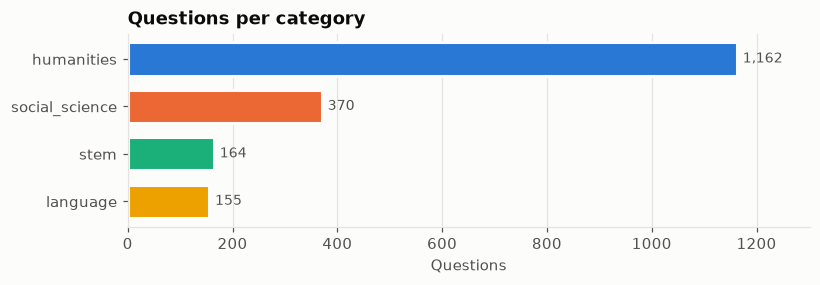

In [7]:
cat = (df.groupby("category")
         .agg(questions=("id", "size"), subjects=("subject", "nunique"))
         .sort_values("questions", ascending=False))
cat["share_%"] = (100 * cat.questions / cat.questions.sum()).round(1)
display(cat)

CAT_ORDER = cat.index.tolist()
CAT_COLOR = dict(zip(CAT_ORDER, SERIES))
hbar(cat.questions, "Questions per category",
     color=[CAT_COLOR[c] for c in cat.questions.sort_values().index]);

### 3.2 By subject

In [8]:
subj = (df.groupby(["subject", "category"])
          .agg(questions=("id", "size"),
               sinhala_name=("subject_original", "first"),
               grades=("grade", lambda g: ", ".join(map(str, sorted(g.unique())))),
               years=("year", lambda y: ", ".join(map(str, sorted(y.unique())))))
          .reset_index()
          .sort_values("questions", ascending=False)
          .reset_index(drop=True))
subj["share_%"] = (100 * subj.questions / subj.questions.sum()).round(1)
display(subj)
print(f"Subjects: {len(subj)}   min {subj.questions.min()}   median {subj.questions.median():.0f}   "
      f"max {subj.questions.max()}   max/min ratio {subj.questions.max() / subj.questions.min():.2f}")

,subject,category,questions,sinhala_name,grades,years,share_%
0,Science,stem,164,විද්‍යාව,"6, 7, 8","2019, 2020, 2022, 2023",8.9
1,Buddhism,humanities,162,බුද්ධ ධර්මය,"6, 7, 8","2019, 2020, 2023",8.8
2,Sinhala Language and Literature,language,155,සිංහල භාෂාව සහ සාහිත්‍යය,"6, 7, 8","2019, 2020, 2022, 2023",8.4
3,History,humanities,151,ඉතිහාසය,"6, 7, 8","2018, 2019, 2020, 2022, 2023",8.2
4,Eastern Music,humanities,143,පෙරදිග සංගීතය,"6, 7, 8","2018, 2019, 2020, 2021, 2022, 2023",7.7
5,Catholicism,humanities,132,කතෝලික ධර්මය,"6, 7, 8","2018, 2019, 2022, 2023",7.1
6,Health and Physical Science,social_science,130,සෞඛ්‍ය හා ශාරීරික විද්‍යාව,"6, 7, 8","2018, 2019, 2020, 2022, 2023",7.0
7,Christianity,humanities,130,ක්‍රිස්තියානි ධර්මය,"6, 7, 8","2018, 2019, 2022, 2023",7.0
8,Drama and Theatre,humanities,128,නාට්‍ය හා රංග කලාව,"6, 7, 8","2019, 2020, 2022, 2023",6.9
9,Civics,social_science,123,පුරවැසි අධ්‍යාපනය,"6, 7, 8","2018, 2019, 2020, 2022, 2023",6.6


Subjects: 14   min 100   median 130   max 164   max/min ratio 1.64


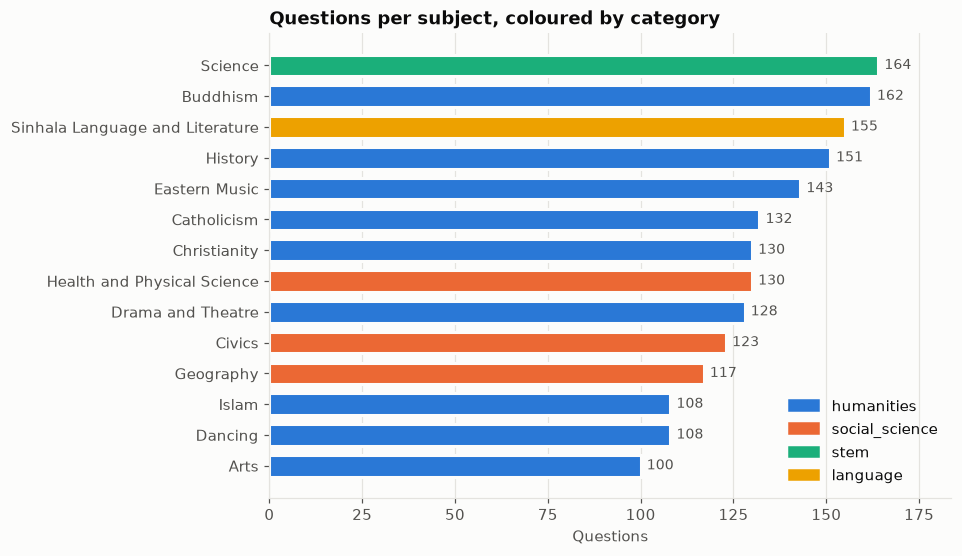

In [9]:
s = subj.set_index("subject").questions.sort_values()
ax = hbar(s, "Questions per subject, coloured by category",
          color=[CAT_COLOR[subj.set_index("subject").category[x]] for x in s.index])
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=CAT_COLOR[c]) for c in CAT_ORDER],
          labels=CAT_ORDER, loc="lower right");

### 3.3 By grade

In [10]:
grade = df.grade.value_counts().sort_index().rename("questions").to_frame()
grade["share_%"] = (100 * grade.questions / len(df)).round(1)
display(grade)

sg = pd.crosstab(df.subject, df.grade, margins=True, margins_name="total")
display(sg.sort_values("total", ascending=False))

,questions,share_%
grade,,
6,584,31.6
7,634,34.3
8,633,34.2


grade,6,7,8,total
subject,,,,
total,584,634,633,1851
Science,47,62,55,164
Buddhism,54,58,50,162
Sinhala Language and Literature,58,44,53,155
History,49,51,51,151
Eastern Music,47,66,30,143
Catholicism,35,40,57,132
Christianity,29,31,70,130
Health and Physical Science,35,43,52,130


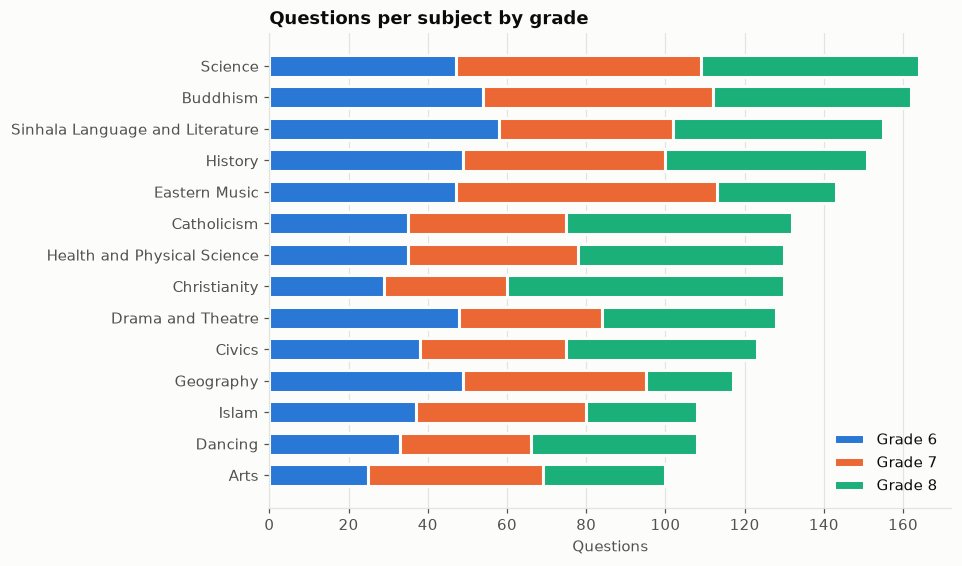

In [11]:
sg_plot = pd.crosstab(df.subject, df.grade)
sg_plot = sg_plot.loc[sg_plot.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(8, 5.6))
left = np.zeros(len(sg_plot))
for i, g in enumerate(sg_plot.columns):
    ax.barh(sg_plot.index, sg_plot[g], left=left, color=SERIES[i], height=0.7,
            edgecolor=SURFACE, linewidth=2, label=f"Grade {g}")
    left += sg_plot[g].values
ax.grid(axis="y", visible=False)
ax.set_title("Questions per subject by grade")
ax.set_xlabel("Questions")
ax.legend(loc="lower right");

### 3.4 By year

,questions,share_%
year,,
2018,111,6.0
2019,846,45.7
2020,317,17.1
2021,3,0.2
2022,246,13.3
2023,328,17.7


year,2018,2019,2020,2021,2022,2023,total
subject,,,,,,,
total,111,846,317,3,246,328,1851
Science,0,54,46,0,14,50,164
Buddhism,0,67,67,0,0,28,162
Sinhala Language and Literature,0,56,50,0,17,32,155
History,2,50,24,0,15,60,151
Eastern Music,10,65,27,3,30,8,143
Catholicism,23,60,0,0,29,20,132
Christianity,8,72,0,0,27,23,130
Health and Physical Science,1,64,21,0,6,38,130


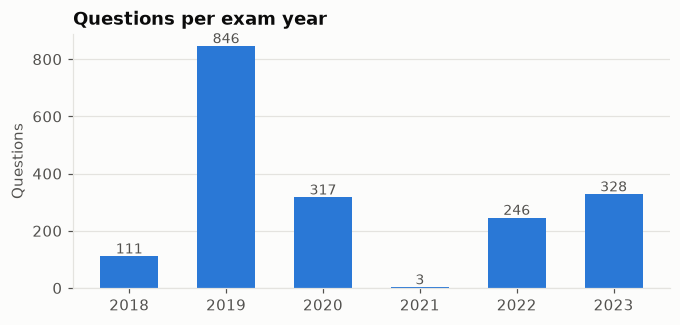

In [12]:
year = df.year.value_counts().sort_index().rename("questions").to_frame()
year["share_%"] = (100 * year.questions / len(df)).round(1)
display(year)
display(pd.crosstab(df.subject, df.year, margins=True, margins_name="total").sort_values("total", ascending=False))

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(year.index.astype(str), year.questions, color=BLUE, width=0.6)
ax.grid(axis="x", visible=False)
for x, v in enumerate(year.questions):
    ax.text(x, v + 10, f"{v:,}", ha="center", fontsize=9, color=INK2)
ax.set_title("Questions per exam year")
ax.set_ylabel("Questions");

### 3.5 By exam series (`metadata.type`)

The code is `<issuer>_<region>[_<term>]`: `P` = provincial department of education, `Z` = zonal education office.
Province codes: `NWP` North Western, `CP` Central, `SP` Southern, `NCP` North Central, `WP` Western.
The trailing digit is the school term (1st, 2nd or 3rd term test).

,questions,issuer,region,term,subjects
type,,,,,
P_NWP_3,366,Provincial,North Western,3.0,11
P_CP,276,Provincial,Central,NaN,12
(missing),251,(missing),(missing),NaN,2
P_NWP_2,245,Provincial,North Western,2.0,12
Z_Mathugama,206,Zonal,Mathugama zone,NaN,10
P_SP_3,164,Provincial,Southern,3.0,7
P_NWP_1,133,Provincial,North Western,1.0,9
P_SP,85,Provincial,Southern,NaN,7
P_SP_2,39,Provincial,Southern,2.0,3


,questions,share_%
region,,
North Western,744,40.2
Southern,288,15.6
Central,276,14.9
(missing),251,13.6
Mathugama zone,206,11.1
North Central,53,2.9
Western,33,1.8


,questions
term,
NaN,851
3.0,549
2.0,318
1.0,133


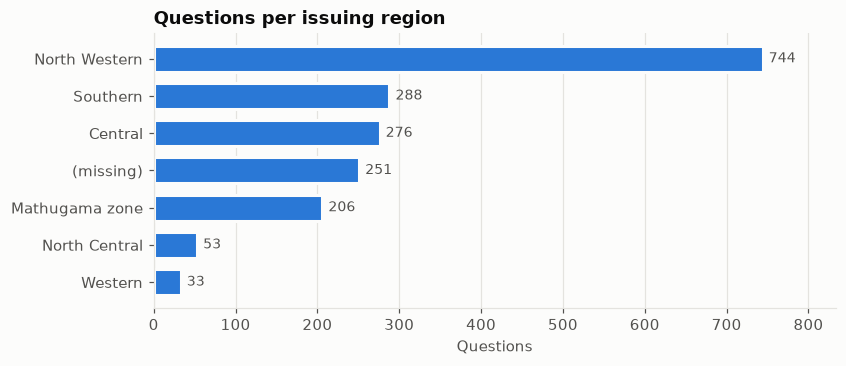

In [13]:
PROVINCE = {"NWP": "North Western", "CP": "Central", "SP": "Southern", "NCP": "North Central", "WP": "Western"}

def decode_type(t):
    if pd.isna(t):
        return pd.Series({"issuer": "(missing)", "region": "(missing)", "term": None})
    parts = t.split("_")
    if parts[0] == "Z":
        return pd.Series({"issuer": "Zonal", "region": parts[1] + " zone", "term": None})
    return pd.Series({"issuer": "Provincial", "region": PROVINCE.get(parts[1], parts[1]),
                      "term": int(parts[2]) if len(parts) > 2 else None})

df[["issuer", "region", "term"]] = df.type.apply(decode_type)

types = (df.groupby(df.type.fillna("(missing)"))
           .agg(questions=("id", "size"), issuer=("issuer", "first"), region=("region", "first"),
                term=("term", "first"), subjects=("subject", "nunique"))
           .sort_values("questions", ascending=False))
display(types)

region = df.region.value_counts().rename("questions").to_frame()
region["share_%"] = (100 * region.questions / len(df)).round(1)
display(region)
display(df.term.value_counts(dropna=False).rename("questions").rename_axis("term").to_frame())
hbar(df.region.value_counts(), "Questions per issuing region");

### 3.6 By source

Each record's `source` is the page or file it was transcribed from. Sources fall into a few kinds:
readable pastpapers.wiki article pages (plus one direct PDF link), pastpapers.wiki **file-download endpoints**
(`wp-admin/admin-ajax.php?...`, opaque IDs with no human-readable info), e-Thaksalawa Moodle course pages, and
**local `file://` paths** from an annotator's own Downloads folder.

,questions,distinct_sources,share_%
source_kind,,,
pastpapers.wiki article page,1227,163,66.3
pastpapers.wiki download endpoint,485,52,26.2
e-Thaksalawa (Moodle),93,8,5.0
local file path,37,4,2.0
pastpapers.wiki direct PDF link,9,1,0.5


Distinct raw source strings:       232
Distinct after URL normalisation:  228


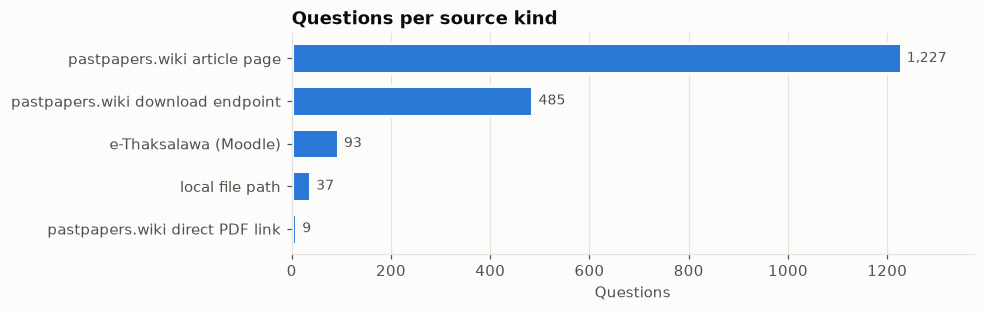

In [14]:
def source_kind(u):
    if u.startswith("file:"):
        return "local file path"
    host = urlparse(u).netloc
    if "thaksalawa" in host:
        return "e-Thaksalawa (Moodle)"
    if "admin-ajax.php" in u:
        return "pastpapers.wiki download endpoint"
    if u.lower().endswith(".pdf"):
        return "pastpapers.wiki direct PDF link"
    return "pastpapers.wiki article page"

def canonical_source(u):
    # Same paper reached via different cache-buster query strings (?swcfpc=1..4, #google_vignette).
    p = urlparse(u)
    if "admin-ajax.php" in u or "thaksalawa" in p.netloc:
        return u
    return f"{p.scheme}://{p.netloc}{unquote(p.path)}".rstrip("/")

df["source_kind"] = df.source.map(source_kind)
df["source_canon"] = df.source.map(canonical_source)
df["source_host"] = df.source.map(lambda u: urlparse(u).netloc or "(local file)")

kinds = (df.groupby("source_kind")
           .agg(questions=("id", "size"), distinct_sources=("source_canon", "nunique"))
           .sort_values("questions", ascending=False))
kinds["share_%"] = (100 * kinds.questions / len(df)).round(1)
display(kinds)
print("Distinct raw source strings:      ", df.source.nunique())
print("Distinct after URL normalisation: ", df.source_canon.nunique())
hbar(kinds.questions, "Questions per source kind");

In [15]:
# How many questions come from each source document, and how many documents back each subject.
per_src = df.groupby("source_canon").size()
print("Questions per source document:")
display(per_src.describe().round(1).to_frame("value").T)

src_subj = (df.groupby("subject")
              .agg(questions=("id", "size"), source_docs=("source_canon", "nunique"),
                   regions=("region", "nunique"), years=("year", "nunique"))
              .sort_values("questions", ascending=False))
src_subj["questions_per_doc"] = (src_subj.questions / src_subj.source_docs).round(1)
src_subj

Questions per source document:


,count,mean,std,min,25%,50%,75%,max
value,228.0,8.1,5.2,1.0,4.8,6.0,10.0,28.0


,questions,source_docs,regions,years,questions_per_doc
subject,,,,,
Science,164,10,5,4,16.4
Buddhism,162,15,4,3,10.8
Sinhala Language and Literature,155,12,4,4,12.9
History,151,19,5,5,7.9
Eastern Music,143,17,1,6,8.4
Catholicism,132,14,3,4,9.4
Health and Physical Science,130,16,5,5,8.1
Christianity,130,15,3,4,8.7
Drama and Theatre,128,17,5,4,7.5


In [16]:
# Most-used individual sources.
top_src = (df.groupby("source_canon")
             .agg(questions=("id", "size"), subject=("subject", "first"), grade=("grade", "first"),
                  year=("year", "first"), type=("type", "first"))
             .sort_values("questions", ascending=False).head(15))
top_src.index = top_src.index.str.slice(0, 110)
top_src

,questions,subject,grade,year,type
source_canon,,,,,
https://pastpapers.wiki/wp-admin/admin-ajax.php?juwpfisadmin=false&action=wpfd&task=file.download&wpfd_categor,28,Sinhala Language and Literature,8,2019,P_CP
https://pastpapers.wiki/wp-admin/admin-ajax.php?juwpfisadmin=false&action=wpfd&task=file.download&wpfd_categor,26,Sinhala Language and Literature,7,2019,P_CP
https://pastpapers.wiki/grade-08-civic-education-3rd-term-test-paper-with-answers-2019-sinhala-medium-central-,21,Civics,8,2019,P_CP
https://pastpapers.wiki/grade-06-buddhism-3rd-term-test-paper-with-answers-2020-sinhala-medium-southern-provin,20,Buddhism,6,2020,P_SP_3
https://pastpapers.wiki/grade-07-buddhism-3rd-term-test-paper-2020-sinhala-medium-southern-province,20,Buddhism,7,2020,P_SP_3
https://pastpapers.wiki/grade-08-science-3rd-term-test-paper-with-answers-2019-sinhala-medium-central-province,20,Science,8,2019,P_CP
https://pastpapers.wiki/wp-admin/admin-ajax.php?juwpfisadmin=false&action=wpfd&task=file.download&wpfd_categor,20,Science,8,2019,P_NWP_3
https://pastpapers.wiki/wp-admin/admin-ajax.php?juwpfisadmin=false&action=wpfd&task=file.download&wpfd_categor,20,Islam,7,2019,NaN
https://pastpapers.wiki/grade-07-history-2nd-term-test-paper-with-answers-2023-mathugama-zone,19,History,7,2023,Z_Mathugama


## 4. Text characteristics

In [17]:
ZW = "\u200d"   # ZERO WIDTH JOINER: a legitimate part of Sinhala spelling (yansaya, rakaransaya, touching letters)

df["q_chars"] = df.question.str.strip().str.len()
df["q_words"] = df.question.str.split().str.len()
df["c_chars_mean"] = df.choices.map(lambda c: np.mean([len(x.strip()) for x in c]))
df["n_choices"] = df.choices.map(len)
df["multiline"] = df.question.str.strip().str.contains("\n")

print("Choices per question:", dict(Counter(df.n_choices)))
lengths = df.groupby("subject").agg(
    q_chars_median=("q_chars", "median"), q_chars_mean=("q_chars", "mean"), q_chars_max=("q_chars", "max"),
    q_words_median=("q_words", "median"), choice_chars_mean=("c_chars_mean", "mean"),
    multiline_q=("multiline", "sum"),
).round(1).sort_values("q_chars_mean", ascending=False)
lengths.loc["ALL"] = [df.q_chars.median(), df.q_chars.mean(), df.q_chars.max(), df.q_words.median(),
                      df.c_chars_mean.mean(), df.multiline.sum()]
lengths.round(1)

Choices per question: {4: 1851}


,q_chars_median,q_chars_mean,q_chars_max,q_words_median,choice_chars_mean,multiline_q
subject,,,,,,
Drama and Theatre,44.0,135.3,668.0,7.0,16.3,32.0
Geography,71.0,96.7,722.0,10.0,11.8,10.0
History,67.0,83.8,546.0,11.0,14.3,11.0
Science,59.5,80.0,393.0,9.5,20.4,19.0
Civics,71.0,78.7,214.0,12.0,25.9,0.0
Health and Physical Science,60.0,77.3,592.0,10.0,18.9,9.0
Buddhism,58.5,66.4,610.0,10.0,20.3,3.0
Arts,63.0,65.3,196.0,9.0,14.1,0.0
Sinhala Language and Literature,52.0,61.3,170.0,10.0,12.1,60.0


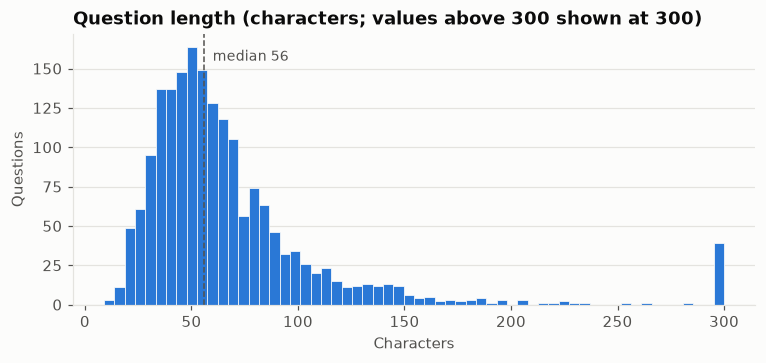

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(df.q_chars.clip(upper=300), bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(df.q_chars.median(), color=INK2, linewidth=1, linestyle="--")
ax.text(df.q_chars.median() + 4, ax.get_ylim()[1] * 0.9, f"median {df.q_chars.median():.0f}", color=INK2, fontsize=9)
ax.grid(axis="x", visible=False)
ax.set_title("Question length (characters; values above 300 shown at 300)")
ax.set_xlabel("Characters")
ax.set_ylabel("Questions");

**Question styles.** Most stems are *sentence-completion* fragments ending in a comma (e.g. `... වන්නේ,` = "... is,"),
inherited from the printed papers. Others are direct questions (`?`) or instructions (`.`). Negatively phrased stems
(`නොවන / නොවේ / නැති` = "not") are a known MCQ difficulty factor. "Statement-combination" items list statements
labelled A–E in the stem and use letters as choices; they only make sense together with the stem layout.

In [19]:
def ending(q):
    q = q.strip()
    return {",": "comma (completion)", "?": "question mark", ".": "full stop"}.get(q[-1], "no punctuation")

LETTER_CHOICE = re.compile(r"\s*[A-E]\s*((,|හා|සහ|and|&)\s*[A-E]\s*)*(පමණි|ද)?\.?\s*")

df["stem_style"] = df.question.map(ending)
df["negated"] = df.question.str.contains(r"නොවන|නොවේ|නැති|නොමැති")
df["letter_choices"] = df.choices.map(lambda c: sum(bool(LETTER_CHOICE.fullmatch(x)) for x in c) >= 3)
df["has_latin"] = (df.question + " " + df.choices.str.join(" ")).str.contains(r"[A-Za-z]{2,}")
df["numeric_choices"] = df.choices.map(lambda c: all(re.fullmatch(r"[\d\s.,:/%-]+", x.strip()) for x in c))

style = pd.DataFrame({
    "questions": [
        *df.stem_style.value_counts().values,
        df.negated.sum(), df.letter_choices.sum(), df.multiline.sum(), df.numeric_choices.sum(), df.has_latin.sum(),
    ]},
    index=[*("stem ends with " + df.stem_style.value_counts().index),
           "negatively phrased stem", "statement-combination (letter choices)", "multi-line stem",
           "all-numeric choices", "contains Latin-script words"])
style["share_%"] = (100 * style.questions / len(df)).round(1)
style

,questions,share_%
stem ends with comma (completion),1148,62.0
stem ends with full stop,302,16.3
stem ends with question mark,264,14.3
stem ends with no punctuation,137,7.4
negatively phrased stem,106,5.7
statement-combination (letter choices),22,1.2
multi-line stem,155,8.4
all-numeric choices,16,0.9
contains Latin-script words,32,1.7


In [20]:
pd.crosstab(df.subject, df.stem_style).assign(
    negated=df.groupby("subject").negated.sum(),
    letter_choices=df.groupby("subject").letter_choices.sum(),
)

stem_style,comma (completion),full stop,no punctuation,question mark,negated,letter_choices
subject,,,,,,
Arts,63,9,21,7,7,0
Buddhism,131,18,6,7,6,0
Catholicism,120,5,1,6,2,0
Christianity,100,9,6,15,6,0
Civics,58,13,1,51,7,0
Dancing,64,14,23,7,2,0
Drama and Theatre,75,22,26,5,17,15
Eastern Music,114,17,1,11,7,1
Geography,21,58,2,36,4,0


In [21]:
# Characters outside the Sinhala block and basic ASCII.
other = Counter(ch for t in df.question.tolist() + [x for c in df.choices for x in c]
                for ch in t if ord(ch) > 127 and not 0x0D80 <= ord(ch) <= 0x0DFF)
pd.DataFrame([{"char": repr(ch), "codepoint": f"U+{ord(ch):04X}", "name": unicodedata.name(ch, "?"), "count": n}
              for ch, n in other.most_common()])

,char,codepoint,name,count
0,'\u200d',U+200D,ZERO WIDTH JOINER,2731
1,'\u200c',U+200C,ZERO WIDTH NON-JOINER,75
2,'°',U+00B0,DEGREE SIGN,28
3,'”',U+201D,RIGHT DOUBLE QUOTATION MARK,21
4,'→',U+2192,RIGHTWARDS ARROW,12
5,'½',U+00BD,VULGAR FRACTION ONE HALF,9
6,'’',U+2019,RIGHT SINGLE QUOTATION MARK,8
7,'‘',U+2018,LEFT SINGLE QUOTATION MARK,6
8,'“',U+201C,LEFT DOUBLE QUOTATION MARK,5
9,'˝',U+02DD,DOUBLE ACUTE ACCENT,4


## 5. Answer key

With 4 options a perfectly balanced key would put 25% of answers in each position. Position bias matters
because LLMs have their own position preferences, and a skewed key rewards or penalises those preferences.

,questions,share_%
answer,,
1,473,25.6
2,501,27.1
3,506,27.4
4,370,20.0


Chi-square vs uniform: chi2 = 26.0, p = 9.4e-06  (n = 1850)


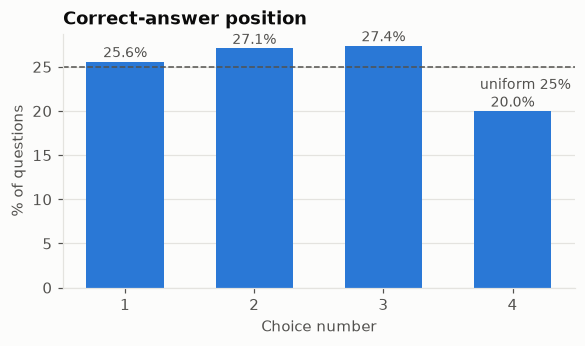

In [22]:
valid = df[df.answer.between(1, 4)]
pos = valid.answer.value_counts().sort_index().rename("questions").to_frame()
pos["share_%"] = (100 * pos.questions / len(valid)).round(1)
chi = chisquare(pos.questions)
display(pos)
print(f"Chi-square vs uniform: chi2 = {chi.statistic:.1f}, p = {chi.pvalue:.2g}  (n = {len(valid)})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(pos.index.astype(str), pos["share_%"], color=BLUE, width=0.6)
ax.axhline(25, color=INK2, linestyle="--", linewidth=1)
ax.text(3.45, 22.5, "uniform 25%", color=INK2, fontsize=9, ha="right")
for x, v in enumerate(pos["share_%"]):
    ax.text(x, v + 0.5, f"{v}%", ha="center", fontsize=9, color=INK2)
ax.grid(axis="x", visible=False)
ax.set_title("Correct-answer position")
ax.set_xlabel("Choice number")
ax.set_ylabel("% of questions");

In [23]:
# Per subject: answer-position shares and a chi-square test against uniform.
rows = []
for s_, g in valid.groupby("subject"):
    counts = g.answer.value_counts().reindex([1, 2, 3, 4], fill_value=0)
    rows.append({"subject": s_, "n": len(g),
                 **{f"pos{k}_%": round(100 * v / len(g), 1) for k, v in counts.items()},
                 "p_value": chisquare(counts).pvalue})
per_subj_pos = pd.DataFrame(rows).set_index("subject").sort_values("p_value")

from matplotlib.colors import LinearSegmentedColormap
blues = LinearSegmentedColormap.from_list("blues", ["#fcfcfb", "#86b6ef", "#256abf"])
(per_subj_pos.style
   .background_gradient(cmap=blues, subset=[f"pos{k}_%" for k in range(1, 5)], vmin=10, vmax=40)
   .format({"p_value": "{:.3f}", **{f"pos{k}_%": "{:.1f}" for k in range(1, 5)}}))

,n,pos1_%,pos2_%,pos3_%,pos4_%,p_value
subject,,,,,,
Eastern Music,143,19.6,32.9,29.4,18.2,0.030
Geography,116,25.0,32.8,26.7,15.5,0.069
Arts,100,29.0,31.0,26.0,14.0,0.073
Catholicism,132,28.8,30.3,24.2,16.7,0.115
Civics,123,23.6,21.1,34.1,21.1,0.128
Christianity,130,20.8,32.3,26.9,20.0,0.158
Buddhism,162,30.2,26.5,24.7,18.5,0.198
Drama and Theatre,128,26.6,21.1,32.0,20.3,0.207
Science,164,18.9,23.8,28.0,29.3,0.227


**Trivial baselines.** Any model score should be read against what you get without understanding the question.

In [24]:
def longest(c):
    lens = [len(x.strip()) for x in c]
    return int(np.argmax(lens)) + 1

base = {
    "random guess (expected)": 0.25,
    "always choice 3 (most common position)": (valid.answer == pos.questions.idxmax()).mean(),
    "pick the longest choice": (valid.choices.map(longest) == valid.answer).mean(),
    "pick the shortest choice": (valid.choices.map(lambda c: int(np.argmin([len(x.strip()) for x in c])) + 1)
                                 == valid.answer).mean(),
}
pd.Series(base, name="accuracy").mul(100).round(1).to_frame("accuracy_%")

,accuracy_%
random guess (expected),25.0
always choice 3 (most common position),27.4
pick the longest choice,29.7
pick the shortest choice,22.7


## 6. Data-quality audit

Each check below collects the affected rows and appends a line to `issues`, which is summarised at the end.

In [25]:
issues = []

def log_issue(check, severity, affected, fix, examples=None):
    ids = list(affected.id) if isinstance(affected, pd.DataFrame) else list(affected)
    issues.append({"check": check, "severity": severity, "affected": len(ids),
                   "examples": ", ".join(map(str, ids[:3])), "suggested fix": fix})

### 6.1 Answer outside the valid range

In [26]:
bad_ans = df[~df.answer.between(1, 4)]
display(bad_ans[["id", "question", "choices", "answer"]])
for _, r in bad_ans.iterrows():
    hit = [i + 1 for i, c in enumerate(r.choices) if c.strip() == str(r.answer)]
    print(f"{r.id}: answer={r.answer!r} matches choice text -> index {hit}")
log_issue("answer not a valid 1–4 index", "high", bad_ans,
          "Answer was stored as the choice text ('24') instead of its index; set it to 3.")

,id,question,choices,answer
1089,Geography_social_science_easy_f_117::64,දේශාංශ පදනම් කරගනිමින් පෘථිවිය සම්මත කාල (වේලා) කලාප කීයකට බෙදා තිබේද?,"[04, 15, 24, 360]",24


Geography_social_science_easy_f_117::64: answer=24 matches choice text -> index [3]


### 6.2 Subject and category labels

In [27]:
lab = (df.groupby(["subject", "subject_raw"]).size().rename("questions").reset_index())
lab["repr"] = lab.subject_raw.map(repr)
display(lab[["subject", "repr", "questions"]])

variant = df[df.groupby("subject").subject_raw.transform(lambda s: s.nunique() > 1)
             & (df.subject_raw != df.groupby("subject").subject_raw.transform(lambda s: s.mode()[0]))]
trailing = df[df.subject_raw != df.subject_raw.str.strip()]
case = sorted(s for s in df.subject_raw.unique() if s[:1].islower())
print("Lower-case subject labels:", case)

log_issue("subject label spelling variants (e.g. 'Eastern_music' vs 'Eastern music')", "medium", variant,
          "Use one canonical subject string per file; derive it from a fixed list.")
log_issue("subject label has trailing whitespace ('drama and Theatre ')", "low", trailing,
          "Strip whitespace; also unify casing ('dancing', 'science', 'drama and Theatre').")

,subject,repr,questions
0,Arts,'Arts',100
1,Buddhism,'Buddhism',162
2,Catholicism,'Catholicism',132
3,Christianity,'Christianity',130
4,Civics,'Civics',123
5,Dancing,'dancing',108
6,Drama and Theatre,'drama and Theatre ',127
7,Drama and Theatre,'drama_and_theatre',1
8,Eastern Music,'Eastern music',142
9,Eastern Music,'Eastern_music',1


Lower-case subject labels: ['dancing', 'drama and Theatre ', 'drama_and_theatre', 'science']


In [28]:
# Taxonomy check: the record's category vs the category in its filename vs the paper's Table 2.
PAPER_DOMAIN = {"History": "humanities", "Drama and Theatre": "humanities", "Dancing": "humanities",
                "Eastern Music": "humanities", "Arts": "humanities", "Buddhism": "humanities",
                "Catholicism": "humanities", "Christianity": "humanities", "Islam": "humanities",
                "Civics": "social_science", "Health and Physical Science": "social_science",
                "Geography": "social_science", "Science": "stem", "Sinhala Language and Literature": "language"}
tax = df.groupby("subject").agg(record_category=("category", lambda c: ", ".join(sorted(c.unique()))),
                                filename_category=("file_category", "first"))
tax["paper_domain"] = tax.index.map(PAPER_DOMAIN)
tax["all_agree"] = (tax.record_category == tax.filename_category) & (tax.record_category == tax.paper_domain)
display(tax)
log_issue("filename category disagrees with record category (History file is '*_social_science_*')", "low",
          df[df.file_category != df.category],
          "Rename the file to match the records (humanities, as in the paper).")

,record_category,filename_category,paper_domain,all_agree
subject,,,,
Arts,humanities,humanities,humanities,True
Buddhism,humanities,humanities,humanities,True
Catholicism,humanities,humanities,humanities,True
Christianity,humanities,humanities,humanities,True
Civics,social_science,social_science,social_science,True
Dancing,humanities,humanities,humanities,True
Drama and Theatre,humanities,humanities,humanities,True
Eastern Music,humanities,humanities,humanities,True
Geography,social_science,social_science,social_science,True


### 6.3 File naming and numbering

In [29]:
mism = files[(files.filename_mismatch != 0) | files.missing_q_no.map(len).gt(0)]
display(mism[["file", "records", "count_in_filename", "filename_mismatch", "q_no_range", "missing_q_no"]])
issues.append({"check": "filename count wrong or q_no gaps", "severity": "low", "affected": len(mism),
               "examples": ", ".join(mism.file.head(3)), "suggested fix":
               "Regenerate filenames from the actual count; renumber q_no or keep a stable id instead."})

,file,records,count_in_filename,filename_mismatch,q_no_range,missing_q_no
0,Arts_humanities_easy_f_97.json,100,97,3,1–100,[]
4,Civics_social_science_easy_f_129.json,123,129,-6,1–123,[]
8,Geography_social_science_easy_f_117.json,117,117,0,1–118,[108]
12,science_stem_easy_f_163.json,164,163,1,1–164,[]


### 6.4 Metadata completeness and provenance

In [30]:
no_type = df[df.type.isna()]
display(no_type.groupby("subject").size().rename("missing type").to_frame())
log_issue("metadata.type is null", "medium", no_type,
          "Fill from the source document (both affected subjects come from identifiable papers).")

local = df[df.source_kind == "local file path"]
display(local.groupby("source").size().rename("questions").to_frame())
log_issue("source is a local file:// path (leaks a user folder, not reproducible)", "high", local,
          "Replace with the public URL of the same paper.")

opaque = df[df.source_kind == "pastpapers.wiki download endpoint"]
log_issue("source is an opaque download endpoint (admin-ajax.php?wpfd_file_id=...)", "medium", opaque,
          "Store the human-readable article URL plus a stable document id and archive copy.")

thak = df[df.source_kind == "e-Thaksalawa (Moodle)"]
log_issue("source is a whole e-Thaksalawa course page, not the specific quiz/paper", "low", thak,
          "Record the specific resource/quiz URL.")

dupurl = df.groupby("source_canon").source.nunique()
dupurl = dupurl[dupurl > 1]
print(f"{len(dupurl)} papers are referenced by more than one URL variant (cache-buster query strings):")
display(df[df.source_canon.isin(dupurl.index)].groupby("source_canon").source.unique().map(len).to_frame("variants"))
log_issue("same paper referenced via different URL variants (?swcfpc=1..4)", "low",
          df[df.source_canon.isin(dupurl.index)], "Strip query strings and fragments from source URLs.")

,missing type
subject,
Eastern Music,143
Islam,108


,questions
source,
file:///C:/Users/User/Downloads/2022-Grade-06-Islam-3rd-Term-Test-Paper-with-Answers-North-Western-Province%20(1).pdf,10
file:///C:/Users/User/Downloads/2022-Grade-07-Islam-3rd-Term-Test-Paper-with-Answers-North-Western-Province%20(1).pdf,9
file:///C:/Users/User/Downloads/Grade-07-Islam-1st-Term-Test-Paper-2018-North-Western-Province.pdf,9
file://C:/Users//Downloads/2022-Grade-08-Islam-3rd-Term-Test-Paper-with-Answers-North-Western-Province.pdf,9


2 papers are referenced by more than one URL variant (cache-buster query strings):


,variants
source_canon,
https://pastpapers.wiki/2022-grade-06-art-3rd-term-test-paper-with-answers-north-western-province,4
https://pastpapers.wiki/2023-grade-08-health-2nd-term-test-paper-with-answers-north-western-province,2


### 6.5 Metadata consistent with the source?

Readable source URLs and file names carry grade, year, term and province in their slug
(e.g. `grade-08-civic-education-3rd-term-test-paper-with-answers-2019-sinhala-medium-central-province`).
Parse them and compare with the record's metadata.

In [31]:
SLUG_PROVINCE = [("north-western", "North Western"), ("north-central", "North Central"),
                 ("southern", "Southern"), ("western", "Western"), ("central", "Central"),
                 ("mathugama", "Mathugama zone")]
TERM_WORDS = {"1st": 1, "first": 1, "2nd": 2, "second": 2, "3rd": 3, "third": 3}

def parse_slug(u):
    if "admin-ajax" in u or "thaksalawa" in u:
        return pd.Series({"src_grade": None, "src_year": None, "src_term": None, "src_region": None})
    s = unquote(u).lower().replace("_", "-").replace(" ", "-")
    g = re.search(r"grade-0?(\d{1,2})", s)
    y = re.search(r"(20\d{2})", s)
    t = re.search(r"(1st|2nd|3rd|first|second|third)-term", s)
    reg = next((name for key, name in SLUG_PROVINCE if key + "-province" in s or key + "-zone" in s
                or s.endswith(key)), None)
    return pd.Series({"src_grade": int(g.group(1)) if g else None, "src_year": int(y.group(1)) if y else None,
                      "src_term": TERM_WORDS[t.group(1)] if t else None, "src_region": reg})

slug = df.source.apply(parse_slug)
chk = pd.concat([df[["id", "subject", "grade", "year", "term", "region", "type", "source"]], slug], axis=1)

chk.loc[chk.region == "(missing)", "region"] = None   # missing type is reported in 6.4, not as a mismatch

def comparable(a):
    return chk[a].notna() & chk["src_" + a].notna()

def mismatch(a):
    if a == "region":
        return comparable(a) & (chk[a] != chk["src_" + a])
    return comparable(a) & (pd.to_numeric(chk[a]) != pd.to_numeric(chk["src_" + a]))

checks = {a: mismatch(a) for a in ["grade", "year", "term", "region"]}
summary = pd.DataFrame({
    "comparable": [int(comparable(a).sum()) for a in checks],
    "mismatched": [int(m.sum()) for m in checks.values()],
}, index=list(checks))
display(summary)
print("Missing `type` that the source URL could fill:",
      int((df.type.isna() & chk.src_region.notna()).sum()), "questions")

for field, m in checks.items():
    if m.any():
        bad = chk[m]
        print(f"\n{field} mismatches (grouped by source):")
        display(bad.groupby(["source", field, "src_" + field]).size().rename("questions")
                   .reset_index().assign(source=lambda d: d.source.str.slice(0, 100)))
        log_issue(f"metadata.{field} disagrees with source URL", "medium", bad,
                  "Re-check against the source paper and correct the metadata.")

,comparable,mismatched
grade,1273,0
year,1273,5
term,759,0
region,1147,22


Missing `type` that the source URL could fill: 68 questions

year mismatches (grouped by source):


,source,year,src_year,questions
0,https://pastpapers.wiki/20232024-grade-08-civic-3rd-term-test-paper-north-western-province/?swcfpc=1,2020,2023.0,5



region mismatches (grouped by source):


,source,region,src_region,questions
0,https://pastpapers.wiki/2022-grade-07-sinhala-3rd-term-test-paper-with-answers-north-western-provinc,Central,North Western,11
1,https://pastpapers.wiki/grade-06-dance-3rd-term-test-paper-with-answers-2019-sinhala-medium-central-,North Central,Central,2
2,https://pastpapers.wiki/grade-06-dancing-2nd-term-test-paper-with-answers-2019-sinhala-medium-southe,North Western,Southern,9


### 6.6 Duplicates and near-duplicates

In [32]:
# (a) Duplicate options inside one question.
dup_choice = df[df.choices.map(lambda c: len({x.strip() for x in c}) < len(c))]
display(dup_choice[["id", "question", "choices", "answer"]])
log_issue("question has two identical options", "high", dup_choice,
          "Re-transcribe from the source. Eastern-music items lost notation marks during extraction.")

# (b) Identical stems (choices differ).
stem_key = df.question.str.replace(ZW, "", regex=False).str.replace(r"\s+", " ", regex=True).str.strip(" ,.")
same_stem = df[stem_key.duplicated(keep=False)].assign(stem=stem_key).sort_values("stem")
display(same_stem[["id", "question", "choices", "answer"]])
print("Most of these are generic instructions ('choose the correctly spelled word') with different options, "
      "so they are not true duplicates. They do show how much the stem alone under-specifies the item.")

,id,question,choices,answer
184,Buddhism_humanities_easy_f_162::85,"බුදු සසුනේ අග්‍රදායකයා හා අග්‍රදායිකාව වන්නේ,","[අනේපිඬු සිටුතුමා හා සුජාතාවයි., අනේපිඬු සිටුතුමා හා විශාඛාවයි., බිම්බිසාර රජු හා විශාඛාවයි., අනේපිඬු සිටුතුමා හා සු...",3
597,Civics_social_science_easy_f_129::74,"සමාජයේ යහපතට හේතුවන වෙනත් ආයතන දෙකක් නිවැරදි ව අඩංගු පිළිතුර වන්නේ ,\n","[පාසල හා පුස්තකාලය, පාසල හා ප්‍රජා සංවර්ධන සමිති, පාසල හා පුස්තකාලය, අමද්‍යප ව්‍යාපාර හා ප්‍රජා සංවර්ධන සමිති]",4
946,Eastern_music_humanities_easy_f_143::64,"තීව්‍ර මධ්‍යමය (ම ) හැඳින්වීම සඳහා බටහිර සංගීතයේ දී භාවිතා කරනු ලබන සංකේතය වන්නේ,\n","[F, F, F, G]",1
970,Eastern_music_humanities_easy_f_143::88,"ස රි ග ම රි, .......... රටාවේ හිස්තැනට සුදුසු ස්වර පාදය වන්නේ,\n","[ග ම ප, ග ම ග, ග ග ම, ග ම ප]",2
976,Eastern_music_humanities_easy_f_143::94,"සරල ස්වර පුවරු වාදනයේදී 'ස,රි,ග,ම' යන ස්වර සඳහා පිළිවෙලින් 1, 2, 3, 4 යන ඇඟිලි භාවිත කළේ නම් 4, 3, 4, 2, 1, 2, 1 වශය...","[ම,ග,ම,රි,ස,රි,ස, ම,ග,ම,රි,ස,රි,ස, ස,රි,ම,ග,රි,ස,රි, ග,ම,ග,රි,ස,රි,ස]",2
1200,Health_and_Physical_Science_social_science_easy_f_130::58,"කසළ කළමනාකරණය සඳහා 3 R සංකල්පය යොදා ගැනීම,","[සෞඛ්‍ය සේවාවකි., සෞඛ්‍ය ප්‍රතිපත්තියකි., සෞඛ්‍ය නීතියකි., සෞඛ්‍ය සේවාවකි.]",2
1417,History_social_science_easy_f_151::145,A හා B අක්ෂර නිවැරදිව ගළපන්න .\n\nA\nI ) ථූපාරාමය\nII ) රුවන්වැලි සෑය\nIII ) අභයගිරිය\nIV ) ජේතවනය\n\nB\nA මහසෙන් රජ...,"[DCBA, DBCA, DCAB, DBCA]",1


,id,question,choices,answer
1844,Sinhala_language_and_literature_language_easy_f_155::149,අක්ෂර වින්‍යාසය නිවැරදි පදය තෝරන්න.,"[බික්ෂුණි, භික්ෂුනී, භික්ෂුණී, භික්සුනී]",3
1843,Sinhala_language_and_literature_language_easy_f_155::148,අක්ෂර වින්‍යාසය නිවැරදි පදය තෝරන්න.,"[අධිකරන, අදිකරණ, අදිකරන, අධිකරණ]",4
1717,Sinhala_language_and_literature_language_easy_f_155::22,අනුක්ත නාම පද පමණක් ඇතුළත් පිළිතුර තෝරන්න.,"[මම, අප, ගුරුවරු, ඔවුන්, තෝ, ළමයින්, දැරියක, ගොවියෙකු, තොප, මා, හාවා, මිනිස්සු]",3
1698,Sinhala_language_and_literature_language_easy_f_155::3,අනුක්ත නාම පද පමණක් ඇතුළත් පිළිතුර තෝරන්න.,"[කුරුල්ලෝ, වැඩිහිටියන්, කවීන්., ඔවුන්, සිංහයන්, රෝගීන්., ළමයි, ගුරුවරු, උගතුන්., දරුවන්, වෛද්‍යවරු, තරුණයන්.]",2
1248,Health_and_Physical_Science_social_science_easy_f_130::106,"ආත්ම අභිමානය සහිත පුද්ගලයෙකු සතු ලක්ෂණයක් විය හැක්කේ,","[අන් අයගේ ජයග්‍රහණය පිළිබඳ බිය වෙයි., අන් අය පැරදවීමට උත්සාහ කරයි., වෙනත් පුද්ගලයන් ගැරහීමට ලක් කරයි., අභියෝගවලට නොබ...",4
1257,Health_and_Physical_Science_social_science_easy_f_130::115,"ආත්ම අභිමානය සහිත පුද්ගලයෙකු සතු ලක්ෂණයක් විය හැක්කේ ,\n","[අන් අයගේ ජයග්‍රහණය පිළිබඳ බිය වෙයි ., අන් අය පැරදවීමට උත්සාහ කරයි ., වෙනත් පුද්ගලයන් ගැරහීමට ලක් කරයි ., අභියෝග වලට...",4
1835,Sinhala_language_and_literature_language_easy_f_155::140,"තද්ධිත නාමයක් වන්නේ ,","[දේශීය, රවුම, කාලය, රට]",1
1795,Sinhala_language_and_literature_language_easy_f_155::100,"තද්ධිත නාමයක් වන්නේ ,","[හැකියා, දේශීය, දුවන්නී, කම්කරු]",1
1736,Sinhala_language_and_literature_language_easy_f_155::41,නිවැරදි අක්ෂර වින්‍යාසයෙන් යුතු වචනය තෝරන්න .,"[දර්ශනය, දක්සින, පෝශනය, පරිඝනකය]",1
1735,Sinhala_language_and_literature_language_easy_f_155::40,නිවැරදි අක්ෂර වින්‍යාසයෙන් යුතු වචනය තෝරන්න .,"[ප්‍රථිඵලය, මහළු මිනිසා, පරීක්ෂණය, විෂේස]",3


Most of these are generic instructions ('choose the correctly spelled word') with different options, so they are not true duplicates. They do show how much the stem alone under-specifies the item.


**Near-duplicates.** Stem and options are compared separately with character 3–5-gram TF-IDF cosine similarity
(robust to Sinhala inflection). Dotted blank lines (`.......`) are collapsed first; otherwise they dominate the n-grams
and make unrelated fill-in-the-blank items look identical. Pairs are then sorted into:

* **duplicate**: stem ≥ 0.85 and options ≥ 0.85 and the same correct-answer text. The same item entered twice.
* **key conflict**: stem ≥ 0.85 and options ≥ 0.85 but a *different* correct answer, short stem. Possible answer-key error.
* **passage group**: long stem (≥ 120 chars) shared at ≥ 0.90 but a different answer. Several questions about one
  passage or poem. This is a legitimate format, but the items are not independent.

In [33]:
def norm(t):
    t = t.replace(ZW, "")
    t = re.sub(r"(\.\s*){3,}|…+|_{3,}|-{3,}", " ___ ", t)      # dotted / dashed blanks -> one placeholder
    return re.sub(r"\s+", " ", t).strip(" ,.")

def norm_answer(t):
    return re.sub(r"[\s.,;:]+", "", t.replace(ZW, ""))

def sim_matrix(texts):
    X = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5)).fit_transform(texts)
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0)
    return S

S_stem = sim_matrix(df.question.map(norm))
S_opts = sim_matrix(df.choices.map(lambda c: " | ".join(sorted(norm(x) for x in c))))
ans_text = [norm_answer(c[a - 1]) if 1 <= a <= len(c) else "" for c, a in zip(df.choices, df.answer)]
stem_len = df.question.map(norm).str.len().values

a_idx, b_idx = np.where(np.triu((S_stem >= 0.85) & ((S_opts >= 0.85) | (S_stem >= 0.90)), k=1))
pairs = pd.DataFrame({"a": a_idx, "b": b_idx,
                      "stem_sim": S_stem[a_idx, b_idx], "opts_sim": S_opts[a_idx, b_idx]})
def same_answer(a, b):
    # Does a's correct answer correspond to b's correct option? (fuzzy, so "අයත්ය." matches "අයත්")
    opts = [norm_answer(x) for x in df.choices.iat[b]]
    best = max(range(len(opts)), key=lambda i: SequenceMatcher(None, ans_text[a], opts[i]).ratio())
    return best + 1 == df.answer.iat[b]

pairs["same_answer"] = [same_answer(a, b) for a, b in zip(pairs.a, pairs.b)]
pairs["long_stem"] = np.minimum(stem_len[pairs.a], stem_len[pairs.b]) >= 120

def kind(r):
    if r.opts_sim >= 0.85 and r.same_answer:
        return "duplicate"
    if r.long_stem and r.stem_sim >= 0.90 and not r.same_answer:
        return "passage group"
    if r.opts_sim >= 0.85 and not r.same_answer:
        return "key conflict"
    return None    # short generic stem with different options, e.g. "choose the correct spelling"

pairs["kind"] = pairs.apply(kind, axis=1)
pairs = pairs.dropna(subset=["kind"])
pairs["id_a"], pairs["id_b"] = df.id.values[pairs.a], df.id.values[pairs.b]
pairs["same_source"] = df.source_canon.values[pairs.a] == df.source_canon.values[pairs.b]
pairs["q_a"] = df.question.values[pairs.a]

display(pairs.groupby("kind").agg(pairs=("a", "size"),
                                  items=("a", lambda s: len(set(s) | set(pairs.loc[s.index, "b"])))))
pairs.sort_values(["kind", "stem_sim"], ascending=[True, False])[
    ["kind", "id_a", "id_b", "stem_sim", "opts_sim", "same_answer", "same_source", "q_a"]].round(3)

,pairs,items
kind,,
duplicate,7,14
passage group,38,25


,kind,id_a,id_b,stem_sim,opts_sim,same_answer,same_source,q_a
51,duplicate,Health_and_Physical_Science_social_science_easy_f_130::106,Health_and_Physical_Science_social_science_easy_f_130::115,1.000,0.966,True,True,"ආත්ම අභිමානය සහිත පුද්ගලයෙකු සතු ලක්ෂණයක් විය හැක්කේ,"
47,duplicate,Eastern_music_humanities_easy_f_143::29,Eastern_music_humanities_easy_f_143::33,1.000,0.977,True,True,"ලෝක සංගීතය බෙදෙන ප්‍රධාන කොටස් දෙක වන්නේ,"
52,duplicate,Health_and_Physical_Science_social_science_easy_f_130::107,Health_and_Physical_Science_social_science_easy_f_130::116,1.000,1.000,True,True,"පාසලේ සෞඛ්‍ය ප්‍රවර්ධනය සඳහා ඔබ ඔබට කළ හැකි කාර්යයක් වන්නේ,"
46,duplicate,Eastern_music_humanities_easy_f_143::4,Eastern_music_humanities_easy_f_143::11,1.000,0.987,True,False,"සර්පිනාව පිළිබඳ නිවැරදි කියමන වනුයේ,"
50,duplicate,Health_and_Physical_Science_social_science_easy_f_130::22,Health_and_Physical_Science_social_science_easy_f_130::31,0.960,1.000,True,False,එදිනෙදා කාර්යයන් සඳහා උදව් වන ක්‍රියාකාරකම් තුළින් වර්ධනය කරගත හැකි ගුණාංග ශාරීරික යෝග්‍යතා ලෙස හැඳින් වේ. මින් ශාරී...
53,duplicate,Health_and_Physical_Science_social_science_easy_f_130::108,Health_and_Physical_Science_social_science_easy_f_130::117,0.910,1.000,True,True,"ආචාර පෙළපාලියක ප්‍රධාන අමුත්තා සිටින පීඨිකාව පසු කළ පසු ""පෙරට... බලන් ..."" යන විධානය දෙනු ලබන්නේ පහත කවුරුන් විසින්ද?"
49,duplicate,Health_and_Physical_Science_social_science_easy_f_130::11,Health_and_Physical_Science_social_science_easy_f_130::28,0.852,1.000,True,False,"කායික යහපැවැත්ම තීරණය කිරීමට භාවිතා කළ හැකි ලක්‍ෂණයක් වන්නේ,"
34,passage group,drama_and_theatre_humanities_easy_f_128::85,drama_and_theatre_humanities_easy_f_128::87,0.977,1.000,False,True,පහත දැක්වෙන පද්‍ය ඛන්ඩ ඇසුරෙන් පහත ප්‍රශ්නයට පිළිතුරු සපයන්න.\n A ඉදින් බබෝ ඉදින් - මගේ අතේ ඉදින්\n ...
19,passage group,drama_and_theatre_humanities_easy_f_128::32,drama_and_theatre_humanities_easy_f_128::34,0.977,0.003,False,True,"පහත සඳහන් A,B,C,D,E කොටස් ඇසුරෙන් පහත ප්‍රශ්නවලට පිළිතුරු සපයන්න.\n\nA. "" මව්පිය දෙදෙනාට සලකාපන්නේ\nහිරිහැර කෙරුමට ස..."
36,passage group,drama_and_theatre_humanities_easy_f_128::86,drama_and_theatre_humanities_easy_f_128::87,0.969,0.675,False,True,පහත දැක්වෙන පද්‍ය ඛන්ඩ ඇසුරෙන් පහත ප්‍රශ්නයට පිළිතුරු සපයන්න.\n A ඉදින් බබෝ ඉදින් - මගේ අතේ ඉදින්\n ...


In [34]:
dups = pairs[pairs.kind == "duplicate"]
conf = pairs[pairs.kind == "key conflict"]
pg   = pairs[pairs.kind == "passage group"]
ids_of = lambda p: sorted(set(p.id_a) | set(p.id_b))

log_issue("duplicate item (same stem, options and answer)", "medium", ids_of(dups),
          "Keep one copy. Several come from the same paper entered twice via different URLs.")
if len(conf):
    log_issue("possible answer-key conflict (same item, different answer)", "high", ids_of(conf),
              "Check both against the source marking scheme.")
log_issue("passage-group items (several questions share one long passage)", "info", ids_of(pg),
          "Add a `group_id` and keep each group in one split.")

# Do related items straddle the existing train/val/test split?
if (SPLIT_DIR / "train.jsonl").exists():
    split_of = {}
    for name in ["train", "val", "test"]:
        with open(SPLIT_DIR / f"{name}.jsonl", encoding="utf-8") as f:
            split_of.update({json.loads(l)["id"]: name for l in f if l.strip()})
    pairs["split_a"], pairs["split_b"] = pairs.id_a.map(split_of), pairs.id_b.map(split_of)
    cross = pairs[pairs.split_a != pairs.split_b]
    print(f"{len(cross)} of {len(pairs)} related pairs sit in different splits:")
    display(cross.groupby(["kind", "split_a", "split_b"]).size().rename("pairs").to_frame())
    log_issue("related items (duplicates / passage groups) straddle train/val/test", "medium", ids_of(cross),
              "Group related items before splitting (e.g. GroupShuffleSplit on a group_id).")
else:
    print("data/splits not found; run 01_data_split.ipynb to check leakage.")

9 of 45 related pairs sit in different splits:


pairs
kind          split_a split_b       
duplicate     test    train        1
              train   test         1
passage group test    train        1
              train   test         1
                      val          4
              val     train        1

### 6.7 Text hygiene and extraction artefacts

In [35]:
ws_q = df[df.question != df.question.str.strip()]
ws_c = df[df.choices.map(lambda c: any(x != x.strip() for x in c))]
runs = df[df.question.str.contains(r"[ \t]{5,}")]
invis = df[df.question.str.contains("[\u200b\u200c\ufeff]") |
           df.choices.map(lambda c: any(re.search("[\u200b\u200c\ufeff]", x) for x in c))]

log_issue("leading/trailing whitespace or newlines in question", "low", ws_q, "Strip.")
log_issue("leading/trailing whitespace in a choice", "low", ws_c, "Strip.")
log_issue("long runs of spaces in question (lost PDF table/column layout)", "medium", runs,
          "Rebuild the layout (e.g. as a list or Markdown table) or drop the item.")
log_issue("zero-width space / non-joiner / BOM characters", "low", invis,
          "Remove; keep only ZWJ (U+200D) where Sinhala spelling needs it.")

display(runs[["id", "question"]].assign(question=runs.question.str.slice(0, 160)).head(8))
display(invis[["id", "question"]].head(5))

,id,question
197,Buddhism_humanities_easy_f_162::98,1 . විච්ඡාචරණ සම්පන්න ගුණය ලෙසය ...
839,drama_and_theatre_humanities_easy_f_128::85,පහත දැක්වෙන පද්‍ය ඛන්ඩ ඇසුරෙන් පහත ප්‍රශ්නයට පිළිතුරු සපයන්න.\n A ඉදින් බබෝ ඉදින් - මගේ අතේ ඉදින්\n ...
840,drama_and_theatre_humanities_easy_f_128::86,පහත දැක්වෙන පද්‍ය ඛන්ඩ ඇසුරෙන් පහත ප්‍රශ්නයට පිළිතුරු සපයන්න.\n A ඉදින් බබෝ ඉදින් - මගේ අතේ ඉදින්\n ...
841,drama_and_theatre_humanities_easy_f_128::87,පහත දැක්වෙන පද්‍ය ඛන්ඩ ඇසුරෙන් පහත ප්‍රශ්නයට පිළිතුරු සපයන්න.\n A ඉදින් බබෝ ඉදින් - මගේ අතේ ඉදින්\n ...
842,drama_and_theatre_humanities_easy_f_128::88,පහත දැක්වෙන පද්‍ය ඛන්ඩ ඇසුරෙන් පහත ප්‍රශ්නයට පිළිතුරු සපයන්න.\n A ඉදින් බබෝ ඉදින් - මගේ අතේ ඉදින්\n ...
858,drama_and_theatre_humanities_easy_f_128::104,පහත ප්‍රශ්නයට පිළිතුරු සැපයීම සඳහා පහත තොරතුරු උපයෝගී කර ගන්න.\nA - වෙදා නටන්නේ පළමුව සබේට එන්නේ\n යොදා කියන්නේ ...
859,drama_and_theatre_humanities_easy_f_128::105,පහත ප්‍රශ්නයට පිළිතුරු සැපයීම සඳහා පහත තොරතුරු උපයෝගී කර ගන්න.\nA - වෙදා නටන්නේ පළමුව සබේට එන්නේ\n යොදා කියන්නේ ...
860,drama_and_theatre_humanities_easy_f_128::106,පහත ප්‍රශ්නයට පිළිතුරු සැපයීම සඳහා පහත තොරතුරු උපයෝගී කර ගන්න.\nA - වෙදා නටන්නේ පළමුව සබේට එන්නේ\n යොදා කියන්නේ ...


,id,question
7,Arts_humanities_easy_f_97::8,වෙසක් උත්සව සැරසිලි අංග ඇතුළත් පිළිතුර තොරන්න.\n
179,Buddhism_humanities_easy_f_162::80,පෙර භවයක අකුසල කර්‌මයක් හේතුවෙන් මුලු ශරීරයේම කුෂ්ඨ වැළඳීමෙන් දුකට පත් ව බුදු රජාණන් වහන්සේගෙන් පිහිට ලැබූ භික්ෂූන් ...
659,dancing_humanities_easy_f_108::13,"උඩරට සම්ප්‍රදායේ ගොඩසරඹ චල දෙවන සරඹයේ කස්තිරම චන්නේ,"
660,dancing_humanities_easy_f_108::14,"මගේ පොඩි යාලු.'............................... මෙම ගීතය රචනා කළේ,"
754,dancing_humanities_easy_f_108::108,"වෛශාක්‍යය මංගල්‍යය' නමින්‌ හැඳින්වෙන්නේ,"


In [36]:
# ZWJ spelling variants: the same word written with and without U+200D (e.g. අක්‍ෂර vs අක්ෂර).
all_text = df.question + " " + df.choices.str.join(" ")
words = all_text.map(lambda t: [w.strip(".,?:;()\"'") for w in t.split()])
by_base = {}
for w, n in Counter(w for ws in words for w in ws).items():
    by_base.setdefault(w.replace(ZW, ""), Counter())[w] += n
zwj_variants = {b: dict(v) for b, v in by_base.items() if len(v) > 1}
print(f"{len(zwj_variants)} words appear both with and without ZWJ. Examples:")
for b, v in sorted(zwj_variants.items(), key=lambda kv: -sum(kv[1].values()))[:10]:
    print("  ", {repr(k): n for k, n in v.items()})

variant_forms = {k for v in zwj_variants.values() for k in v}
zwj_rows = df[words.map(lambda ws: any(w in variant_forms for w in ws))]
log_issue("inconsistent ZWJ spelling of the same word", "low", zwj_rows,
          "Normalise to one spelling convention so dedup and tokenisation behave consistently.")

13 words appear both with and without ZWJ. Examples:
   {"'ලක්\\u200dෂණයක්'": 5, "'ලක්ෂණයක්'": 28}
   {"'අක්\\u200dෂර'": 3, "'අක්ෂර'": 28}
   {"'ලක්ෂණ'": 13, "'ලක්\\u200dෂණ'": 3}
   {"'ආරක්ෂා'": 14, "'ආරක්\\u200dෂා'": 1}
   {"'ක්ෂණික'": 4, "'ක්\\u200dෂණික'": 4}
   {"'අක්ෂරයක්'": 6, "'අක්\\u200dෂරයක්'": 1}
   {"'සුරක්ෂිත'": 4, "'සුරක්\\u200dෂිත'": 1}
   {"'ප්\\u200dරේක්ෂකයා'": 3, "'ප්\\u200dරේක්\\u200dෂකයා'": 2}
   {"'සාක්ෂි'": 3, "'සාක්\\u200dෂි'": 1}
   {"'දක්ෂිණ'": 3, "'දක්\\u200dෂිණ'": 1}


In [37]:
# Items that depend on layout, notation or lost visuals. Heuristic: worth a manual look, not proof of a defect.
VISUAL = r"රූප සටහන|පහත රූපය|ඉහත රූපය|රූපයේ දැක්වෙ|වර්ධක සටහන|සිතියමේ දැක්වෙ|ප්‍රස්ථාරය|ප්‍රස්තාරය|වගුවේ"
needs_look = df[df.question.str.contains(VISUAL) | df.letter_choices | df.multiline
                | (df.subject.eq("Eastern Music") & df.question.str.contains(r"[`/|]"))]
display(needs_look.groupby("subject").size().rename("items").to_frame())
log_issue("layout/notation-dependent items (matching lists, music notation, figure refs)", "info", needs_look,
          "Tag with a field such as `format` so results can be sliced; verify each renders correctly as text.")

,items
subject,
Buddhism,3
Catholicism,1
Christianity,1
Dancing,1
Drama and Theatre,32
Eastern Music,17
Geography,11
Health and Physical Science,10
History,11


In [38]:
# "All of the above" / "none of the above" style options pin the item to a fixed option order.
AOTA = r"සියල්ල|සියල්ලම|ඉහත සඳහන් සියල්ල|කිසිවක් නොවේ|ඉහත කිසිවක්"
aota = df[df.choices.map(lambda c: any(re.search(AOTA, x) for x in c))]
display(aota[["id", "choices", "answer"]].head(8))
log_issue("'all/none of the above' style options", "info", aota,
          "Flag them; exclude from choice-shuffling or circular evaluation.")

,id,choices,answer
647,dancing_humanities_easy_f_108::1,"[සමබරතාවය රැක ගැනීමට උපකාරී වේ., දරා ගැනීමේ ශක්ති වර්ධනය වේ., නිවැරදි ඉරියව් පවත්වා ගැනීමට හැකි වේ., ඉහත කරුණු සියල්...",4
1158,Health_and_Physical_Science_social_science_easy_f_130::16,"[දිනපතා නෑම හෝ ඇඟ සේදීම., නියපොතු කොටට කපා තිබීම., වැසිකිලි යාමෙන් පසු නිසි පරිදි සබන් යොදා අත් සේදීම., ඉහත සියල්ලම.]",4
1187,Health_and_Physical_Science_social_science_easy_f_130::45,"[නිවැරදි වැතිරීම, නිවැරදි හිඳගැනීම, නිවැරදි ඇවිදීම, ඉහත කිසිවක් නොවේ.]",1
1533,science_stem_easy_f_163::2,"[දුරේක්ෂය, සංයුක්ත අණ්වීක්ෂය, අත්කාචය, ඉහත සියල්ලම]",2
1541,science_stem_easy_f_163::10,"[A පමණක් සත්‍ය වේ., B පමණක් සත්‍ය වේ., B හා C සත්‍ය වේ., A, B හා C සියල්ල සත්‍ය වේ.]",3
1570,science_stem_easy_f_163::39,"[A හා B, B හා C, A හා C, A, B, C සියල්ල]",4
1573,science_stem_easy_f_163::42,"[A හා B, B හා C, A හා C, A, B, C සියල්ල]",1
1578,science_stem_easy_f_163::47,"[කෘෂි කර්මාන්තය සඳහා බහුල ලෙස කෘෂි රසායනික ද්‍රව්‍ය භාවිතය., කර්මාන්ත ශාලා වලින් බැහැර කරන අපද්‍රව්‍ය ජලාශ වලට මුදා ...",4


### 6.8 Audit summary

In [39]:
SEV = {"high": 0, "medium": 1, "low": 2, "info": 3}
audit = (pd.DataFrame(issues)
           .assign(_o=lambda d: d.severity.map(SEV))
           .sort_values(["_o", "affected"], ascending=[True, False])
           .drop(columns="_o").reset_index(drop=True))
audit["share_%"] = (100 * audit.affected / len(df)).round(1)
audit.loc[audit.check.str.startswith("filename count"), "share_%"] = None   # counted in files, not questions
audit[["severity", "check", "affected", "share_%", "examples", "suggested fix"]]

,severity,check,affected,share_%,examples,suggested fix
0,high,"source is a local file:// path (leaks a user folder, not reproducible)",37,2.0,"Islam_humanities_easy_f_108::19, Islam_humanities_easy_f_108::20, Islam_humanities_easy_f_108::21",Replace with the public URL of the same paper.
1,high,question has two identical options,7,0.4,"Buddhism_humanities_easy_f_162::85, Civics_social_science_easy_f_129::74, Eastern_music_humanities_easy_f_143::64",Re-transcribe from the source. Eastern-music items lost notation marks during extraction.
2,high,answer not a valid 1–4 index,1,0.1,Geography_social_science_easy_f_117::64,Answer was stored as the choice text ('24') instead of its index; set it to 3.
3,medium,source is an opaque download endpoint (admin-ajax.php?wpfd_file_id=...),485,26.2,"Buddhism_humanities_easy_f_162::35, Buddhism_humanities_easy_f_162::36, Buddhism_humanities_easy_f_162::37",Store the human-readable article URL plus a stable document id and archive copy.
4,medium,metadata.type is null,251,13.6,"Eastern_music_humanities_easy_f_143::1, Eastern_music_humanities_easy_f_143::2, Eastern_music_humanities_easy_f_143::3",Fill from the source document (both affected subjects come from identifiable papers).
5,medium,metadata.region disagrees with source URL,22,1.2,"dancing_humanities_easy_f_108::10, dancing_humanities_easy_f_108::11, dancing_humanities_easy_f_108::24",Re-check against the source paper and correct the metadata.
6,medium,long runs of spaces in question (lost PDF table/column layout),19,1.0,"Buddhism_humanities_easy_f_162::98, drama_and_theatre_humanities_easy_f_128::85, drama_and_theatre_humanities_easy_f...",Rebuild the layout (e.g. as a list or Markdown table) or drop the item.
7,medium,"duplicate item (same stem, options and answer)",14,0.8,"Eastern_music_humanities_easy_f_143::11, Eastern_music_humanities_easy_f_143::29, Eastern_music_humanities_easy_f_14...",Keep one copy. Several come from the same paper entered twice via different URLs.
8,medium,related items (duplicates / passage groups) straddle train/val/test,14,0.8,"Eastern_music_humanities_easy_f_143::29, Eastern_music_humanities_easy_f_143::33, Health_and_Physical_Science_social...",Group related items before splitting (e.g. GroupShuffleSplit on a group_id).
9,medium,metadata.year disagrees with source URL,5,0.3,"Civics_social_science_easy_f_129::76, Civics_social_science_easy_f_129::77, Civics_social_science_easy_f_129::78",Re-check against the source paper and correct the metadata.


## 7. Comparison with the SinhalaMMLU paper

In [40]:
PAPER_EASY = 1893
print(f"Paper reports {PAPER_EASY:,} easy questions; the Dev Set has {len(df):,} "
      f"({len(df) - PAPER_EASY:+,}, {100 * len(df) / PAPER_EASY:.1f}% of the paper's easy split).")
print(f"Paper: 30 subjects in 6 domains. Dev Set: {df.subject.nunique()} subjects in {df.category.nunique()} categories.")
geo = df[df.subject == "Geography"]
print(f"Geography: {len(geo)} items, all with {geo.n_choices.unique().tolist()} options. The paper says 44 easy "
      "Geography items originally had 3 options and got an LLM-generated 4th. Nothing in the data marks which ones.")

Paper reports 1,893 easy questions; the Dev Set has 1,851 (-42, 97.8% of the paper's easy split).
Paper: 30 subjects in 6 domains. Dev Set: 14 subjects in 4 categories.
Geography: 117 items, all with [4] options. The paper says 44 easy Geography items originally had 3 options and got an LLM-generated 4th. Nothing in the data marks which ones.


| Point | Paper | Dev Set |
|---|---|---|
| Easy questions | 1,893 | 1,851 |
| Main source | e-Thaksalawa + other past-paper sites | ~93% pastpapers.wiki, ~5% e-Thaksalawa |
| History domain | Humanities | `humanities` in the records, but the file is named `History_social_science_...` |
| Province metadata | "recorded" | only implicit in the `type` code; null for 2 subjects |
| LLM-generated distractors | 44 Geography items | present but **not flagged** |
| De-duplication | exact + cosine > 0.95 | 7 duplicate pairs remain. They differ only in whitespace or punctuation, so exact matching missed them (§6.6) |

## 8. Summary and recommendations

In [41]:
print(f"Questions: {len(df):,}   files: {len(files)}   subjects: {df.subject.nunique()}   "
      f"categories: {df.category.nunique()}")
print(f"Grades: {sorted(df.grade.unique().tolist())}   difficulty: {df.difficulty.unique().tolist()}   "
      f"years: {sorted(df.year.unique().tolist())}")
print(f"Humanities share: {100 * (df.category == 'humanities').mean():.1f}%   "
      f"STEM share: {100 * (df.category == 'stem').mean():.1f}% (one subject)")
print(f"Top region: {region.index[0]} ({region['share_%'].iloc[0]}%)   "
      f"top year: {year.questions.idxmax()} ({year['share_%'].max()}%)")
print(f"Answer position shares: {pos['share_%'].to_dict()}   chi2 p = {chi.pvalue:.2g}")
print(f"Longest-choice heuristic: {100 * base['pick the longest choice']:.1f}% vs 25% chance")
print(f"Audit: {len(audit[audit.severity == 'high'])} high, {len(audit[audit.severity == 'medium'])} medium, "
      f"{len(audit[audit.severity == 'low'])} low-severity checks fired")

Questions: 1,851   files: 14   subjects: 14   categories: 4
Grades: [6, 7, 8]   difficulty: ['easy']   years: [2018, 2019, 2020, 2021, 2022, 2023]
Humanities share: 62.8%   STEM share: 8.9% (one subject)
Top region: North Western (40.2%)   top year: 2019 (45.7%)
Answer position shares: {1: 25.6, 2: 27.1, 3: 27.4, 4: 20.0}   chi2 p = 9.4e-06
Longest-choice heuristic: 29.7% vs 25% chance
Audit: 3 high, 8 medium, 9 low-severity checks fired


### What the dataset is

A clean, regular, single-format benchmark of **1,851 four-option Sinhala MCQs** from **grade 6–8 provincial and zonal
term tests** (2018–2023), across 14 subjects. The schema is consistent, every item has exactly 4 choices, and the answer key is
a valid index for all but one item. The content is native Sinhala and culturally grounded: religion, dance, music and drama make
up most of it. Most problems are in **provenance metadata** and **extraction artefacts**. Few are in the questions themselves.

### What should be improved

**1. Correctness (fix before any evaluation)**
* Fix the answer stored as text (`Geography::64`, `answer = 24` → `3`). `src/data.validate` already repairs it, but the raw file is still wrong.
* Re-transcribe the 7 items with **two identical options**. Three are Eastern-music notation that lost its octave/accent marks in extraction (`['F','F','F','G']`). The rest look like copy-paste slips. Where the duplicated option is the keyed answer, the item can't be scored as written.
* Manually review items whose layout was flattened: matching lists, multi-line statements, and stems with long space runs that were PDF tables.

**2. Provenance and metadata**
* Replace the **local `file:///C:/Users/...` paths** with public URLs. They expose an annotator's machine and can't be resolved by anyone else.
* Replace opaque `admin-ajax.php?wpfd_file_id=…` links and whole-course e-Thaksalawa links with document-level URLs, and keep an archived copy (or hash) of every source PDF.
* Fill the **null `type`** for Eastern Music and Islam (251 items; 68 can be filled straight from the source URL). Correct the metadata that disagrees with its source URL (§6.5): 22 items have the wrong province and 5 the wrong year.
* Split `type` into explicit fields: `issuer`, `province/zone`, `term`, `medium`. Add a stable `id` and the question's original number in the paper.
* Add `distractor_origin` (`human` / `llm`) so the LLM-written Geography options can be identified or excluded.
* Normalise labels: one spelling and casing per subject, no `_` vs space variants, no trailing spaces. Fix the filename counts, and rename `History_social_science_*` to match its records (`humanities`).

**3. Balance and coverage**
* Answer positions are skewed (position 4 is under-used overall; Science leans the other way). Rebalance by permuting options at build time (except "all/none of the above" items), or evaluate with **circular / permutation** scoring.
* Humanities is ~63% of the data and STEM is a single subject (Science, 9%). Category-level averages are dominated by a few subjects, so report macro-averages per subject.
* Provenance is concentrated: North Western Province and 2019 papers dominate, and many subjects draw on only a handful of papers. More provinces, years and terms would reduce paper-specific style bias.
* The Dev Set is **easy only**. It can't show how a system behaves on the medium/hard (O/L, A/L, 5-option) items the paper also contains.

**4. Text normalisation**
* Strip leading/trailing whitespace and invisible characters (ZWSP/ZWNJ/BOM). Keep ZWJ, but standardise the spelling of words that appear in both ZWJ and non-ZWJ forms.
* Use one consistent encoding for music notation and for statement-combination items, and tag them with a `format` field.

**5. Implications for this project's pipeline**
* Drop the 7 duplicate copies. `01_data_split.ipynb` stratifies by subject only, so duplicates and passage-group items currently sit on both sides of the train/val/test boundary (§6.6). **Give related items a `group_id` and split by group.**
* Always report scores next to the trivial baselines in §5 (e.g. always-3, longest-choice).
* Slice evaluation results by `stem_style`, `negated` and `format` (statement-combination, passage, notation) to see where models fail, instead of reading only per-subject accuracy.